In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

parquet_file = Path("./results.parquet")
df = pd.read_parquet(parquet_file)

HUE_ORDER = ["prolog", "EdgeWise", "EdgeWise (cr)"]
COL_ORDER = ["arFarming", "distSecurity", "speakToMe"]
PLOTS_DIR = Path("./plots")
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# Set FONT SIZE of x-axis and y-axis, legend, etc.
FONT_SIZE = 14
rc = {
    "axes.labelsize": FONT_SIZE,
    "font.size": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "legend.title_fontsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
}

sns.set_theme(style="whitegrid", palette="colorblind", context="notebook", rc=rc)
pd.set_option("display.max_rows", None)

df = df[df["version"].isin(HUE_ORDER)]

In [2]:
grouping_columns = ["n_event", "topology", "version", "nodes", "application_id", "seed"]
# Identify the groups where "is_placed" is False
events_to_remove = df[(df["callback_id"] == "is_placed") & (df["value"] == "False")][
    grouping_columns
].drop_duplicates()

# Perform an anti-join to remove groups
old_shape = df.shape
df = df.merge(events_to_remove, on=grouping_columns, how="left", indicator=True)
df = df[df["_merge"] == "left_only"].drop(columns=["_merge"])
print(f"Removed {old_shape[0] - df.shape[0]} events")

Removed 29755 events


## EXECUTION TIME

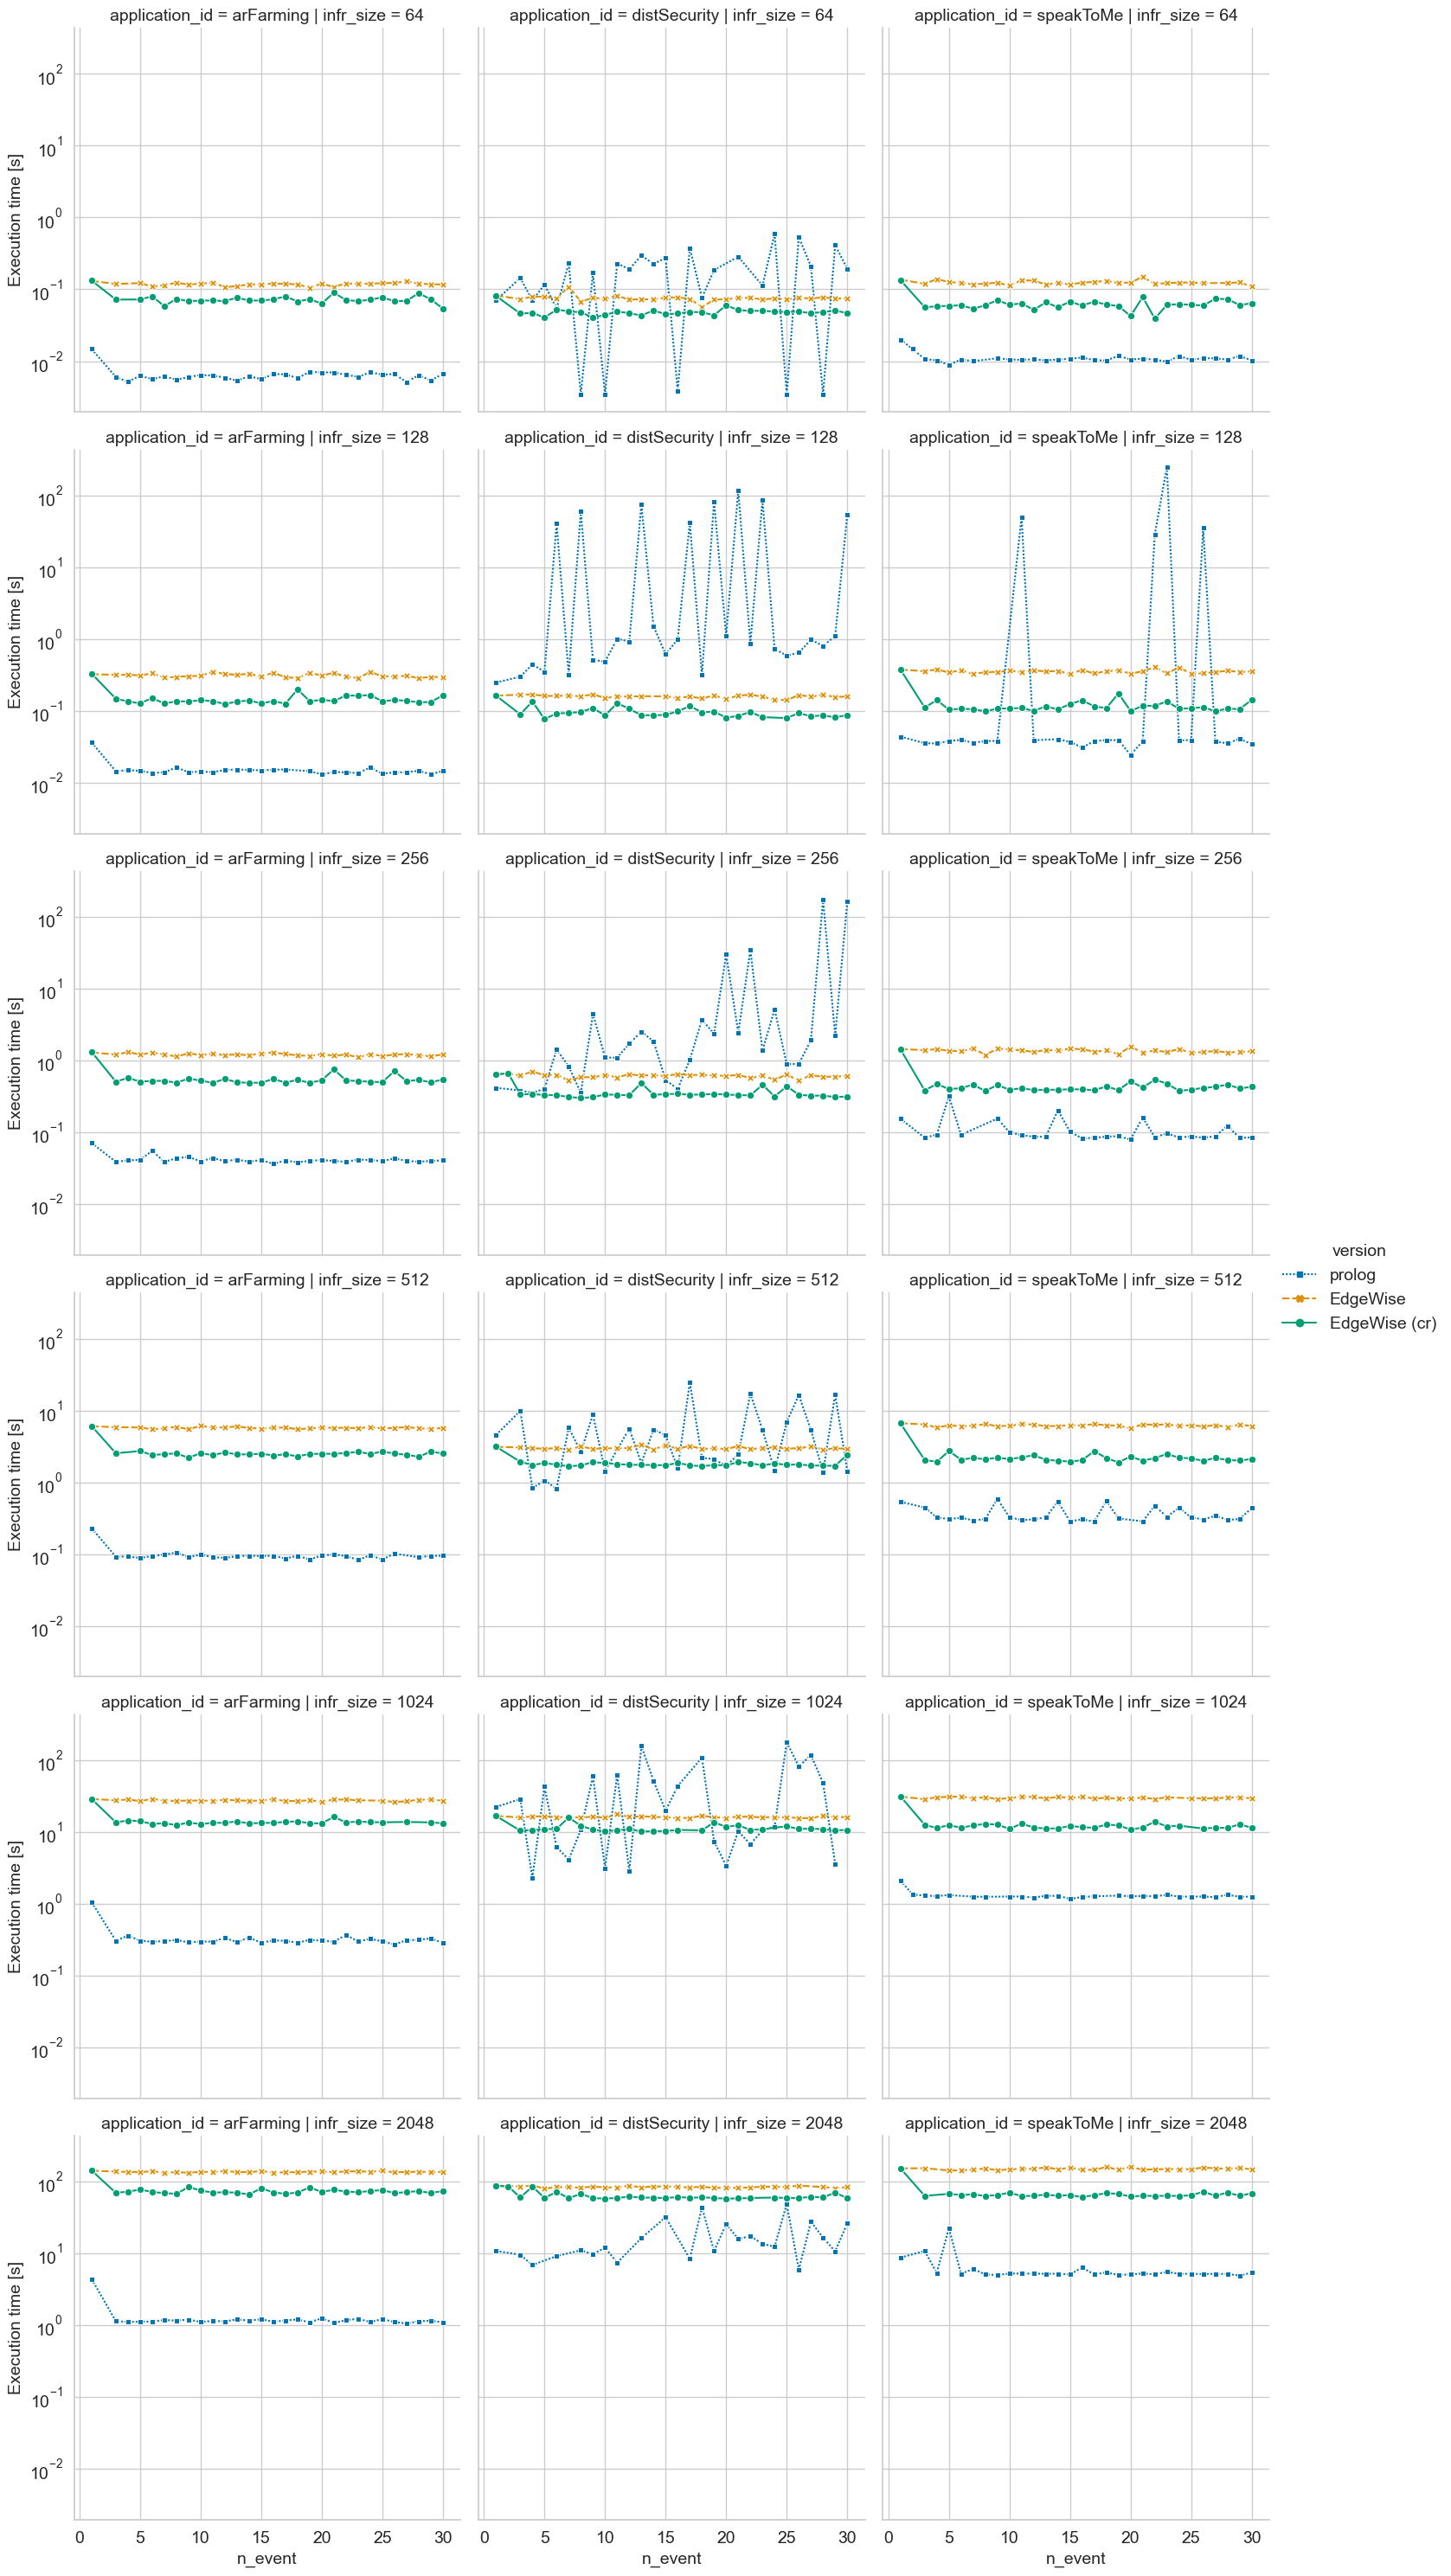

In [3]:
df_exec_time = df[(df["callback_id"] == "execution_time") & (df["value"] != "-1")]
df_exec_time.loc[:, "value"] = df_exec_time["value"].astype(float)
f = sns.relplot(
    data=df_exec_time,
    x="n_event",
    y="value",
    hue="version",
    style="version",
    markers=True,
    kind="line",
    row="nodes",
    col="application_id",
    palette="colorblind",
    errorbar=None,
    col_order=COL_ORDER,
    hue_order=HUE_ORDER,
)
f.set_titles("application_id = {col_name} | infr_size = {row_name}")
f.set(yscale="log")
# f.set(ylim=(0, 160))
f.set_ylabels("Execution time [s]")
f.savefig(PLOTS_DIR / "execution_time.pdf", format="pdf", dpi=600)

### EXEC TIME DIFFERENCE (MILP / MILP (CR))

/var/folders/1r/_v8l8s4s5szdklfbt8tg7dwm0000gn/T/ipykernel_49761/425874073.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  f = sns.relplot(


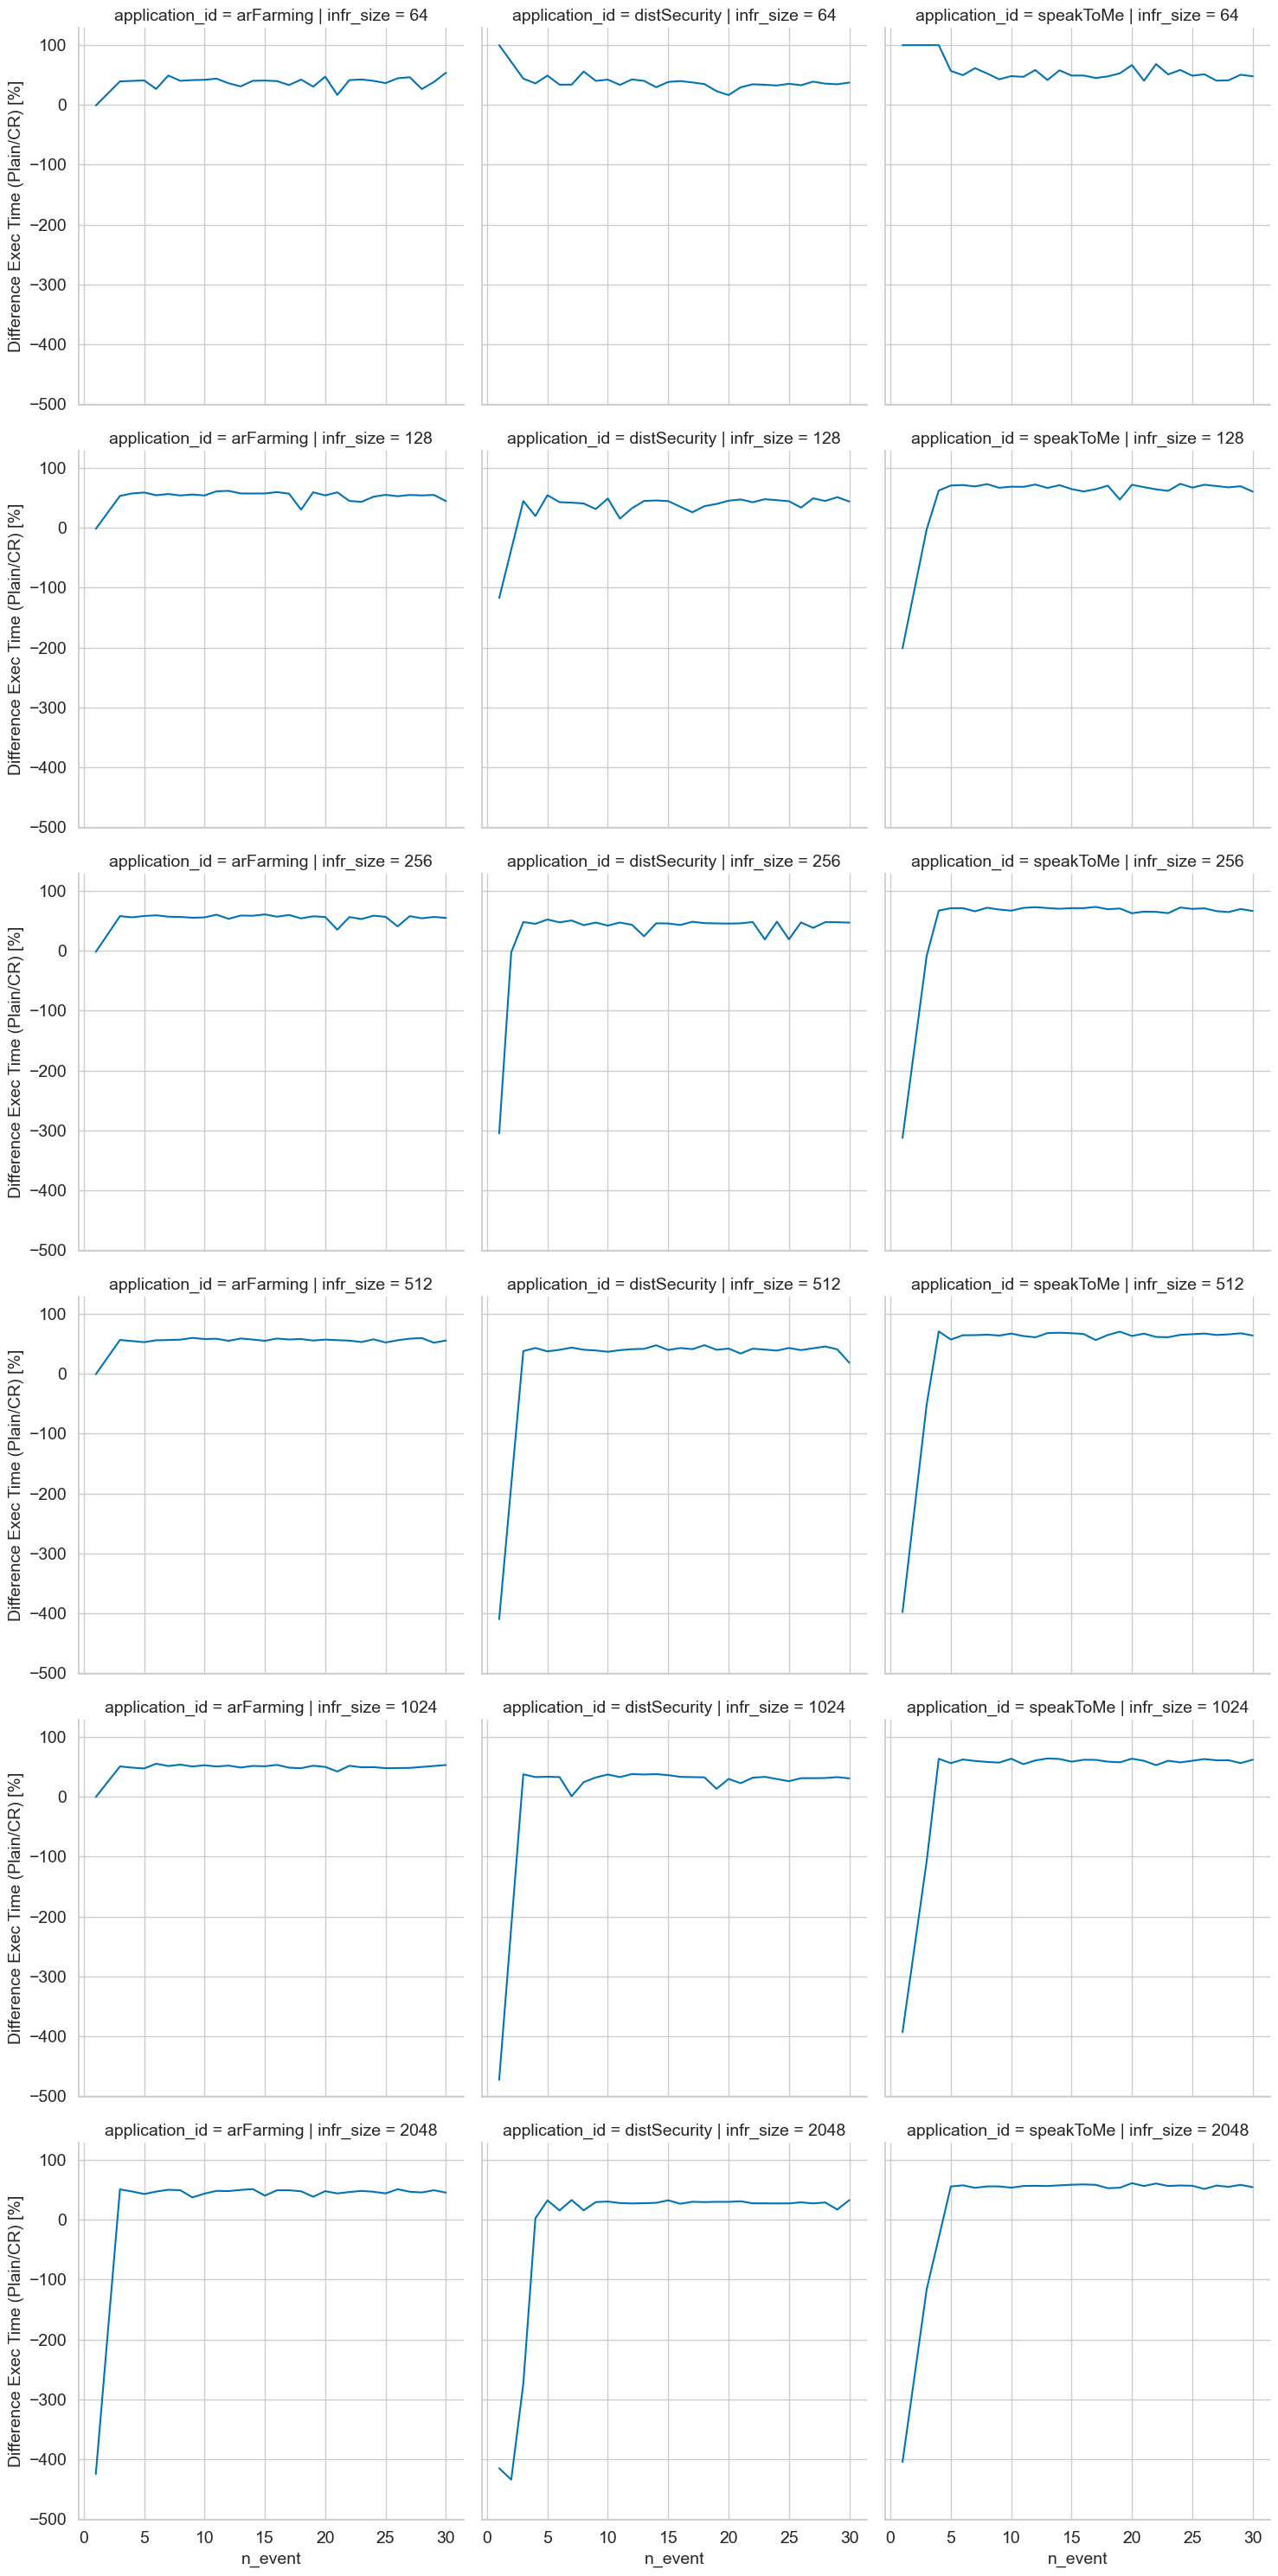

In [4]:
df_milp_et = df_exec_time[df_exec_time["version"] == "EdgeWise"]
df_milp_cr_et = df_exec_time[df_exec_time["version"] == "EdgeWise (cr)"]

df_milp_et = (
    df_milp_et.groupby(["application_id", "nodes", "n_event", "version"])["value"]
    .mean()
    .reset_index()
)
df_milp_cr_et = (
    df_milp_cr_et.groupby(["application_id", "nodes", "n_event", "version"])["value"]
    .mean()
    .reset_index()
)
df_milp_cr_et["diff"] = (
    (df_milp_et["value"] - df_milp_cr_et["value"]) / df_milp_et["value"]
) * 100

f = sns.relplot(
    data=df_milp_cr_et,
    x="n_event",
    y="diff",
    kind="line",
    markers=True,
    row="nodes",
    col="application_id",
    palette="colorblind",
    col_order=COL_ORDER,
    hue_order=HUE_ORDER,
    # errorbar=None,
)
f.set_titles("application_id = {col_name} | infr_size = {row_name}")
f.set_ylabels("Difference Exec Time (Plain/CR) [%]")

## COST

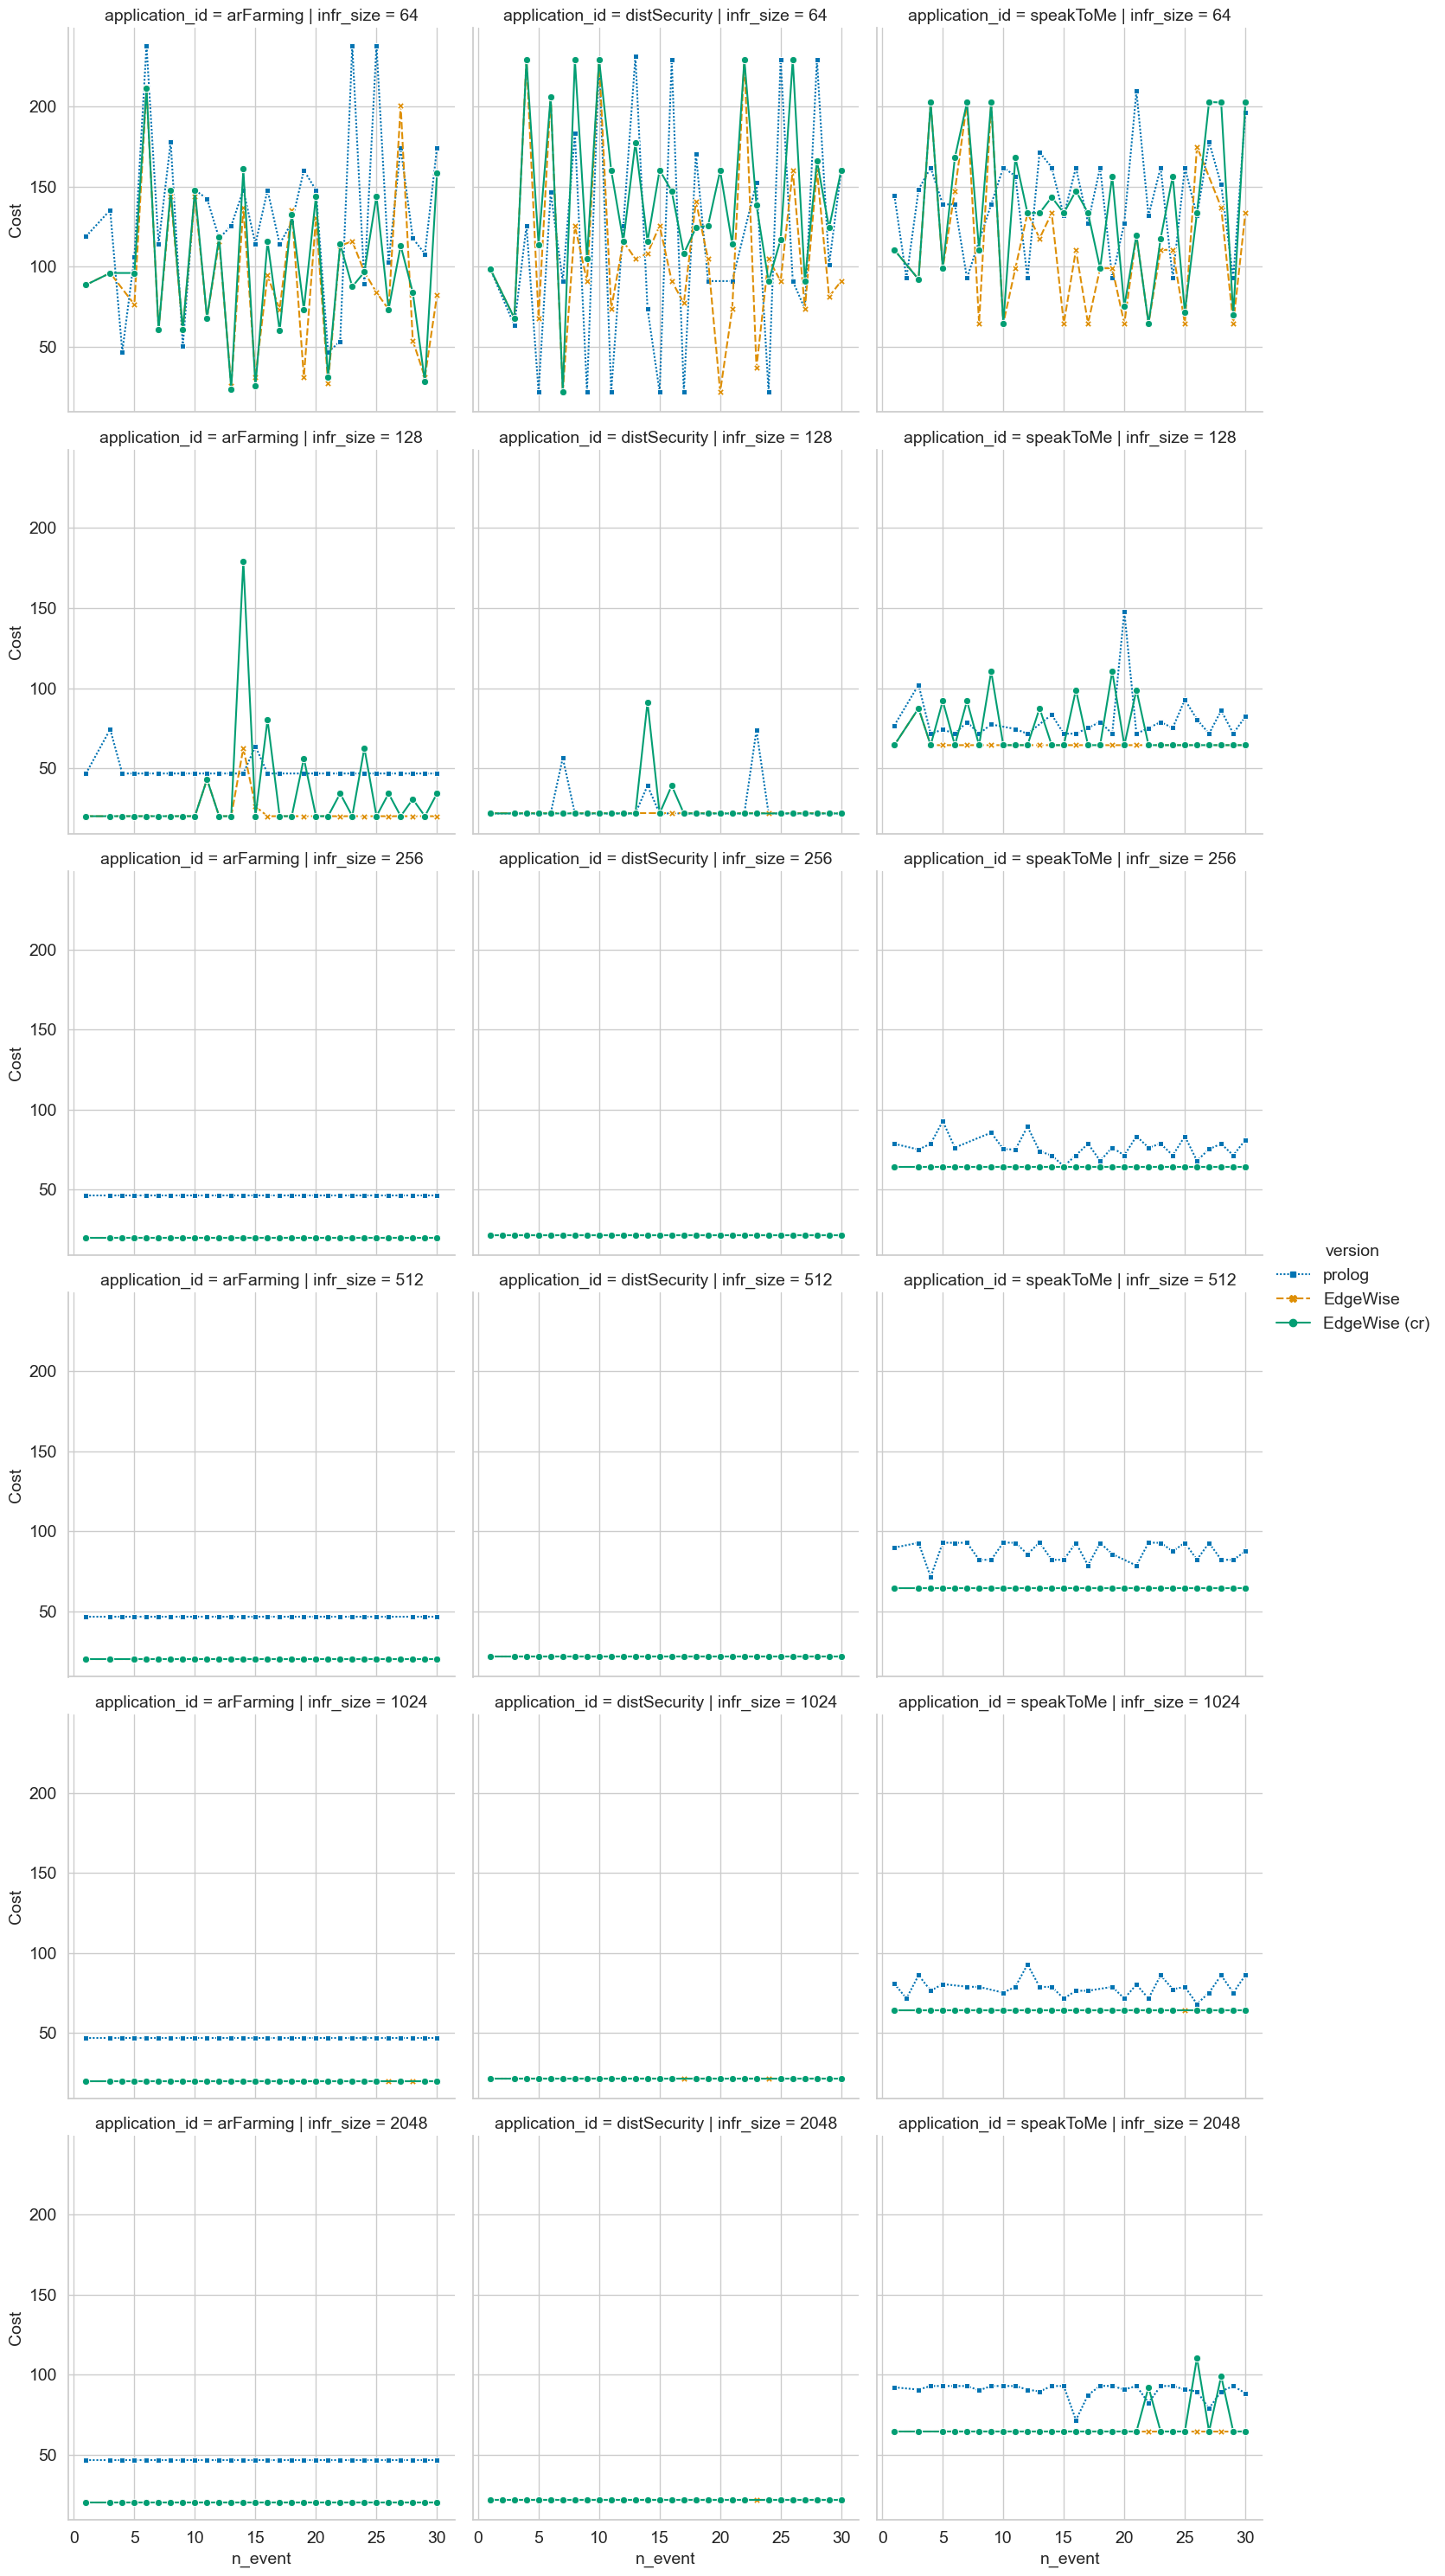

In [5]:
df_cost = df[(df["callback_id"] == "cost") & (~df["value"].isin(["inf", "-1"]))]
df_cost.loc[:, "value"] = df_cost["value"].astype(float)
f = sns.relplot(
    data=df_cost,
    x="n_event",
    y="value",
    hue="version",
    style="version",
    kind="line",
    row="nodes",
    col="application_id",
    palette="colorblind",
    col_order=COL_ORDER,
    hue_order=HUE_ORDER,
    markers=True,
    errorbar=None,
)
f.set_titles("application_id = {col_name} | infr_size = {row_name}")
f.set_ylabels("Cost")

## MOVED SERVICES

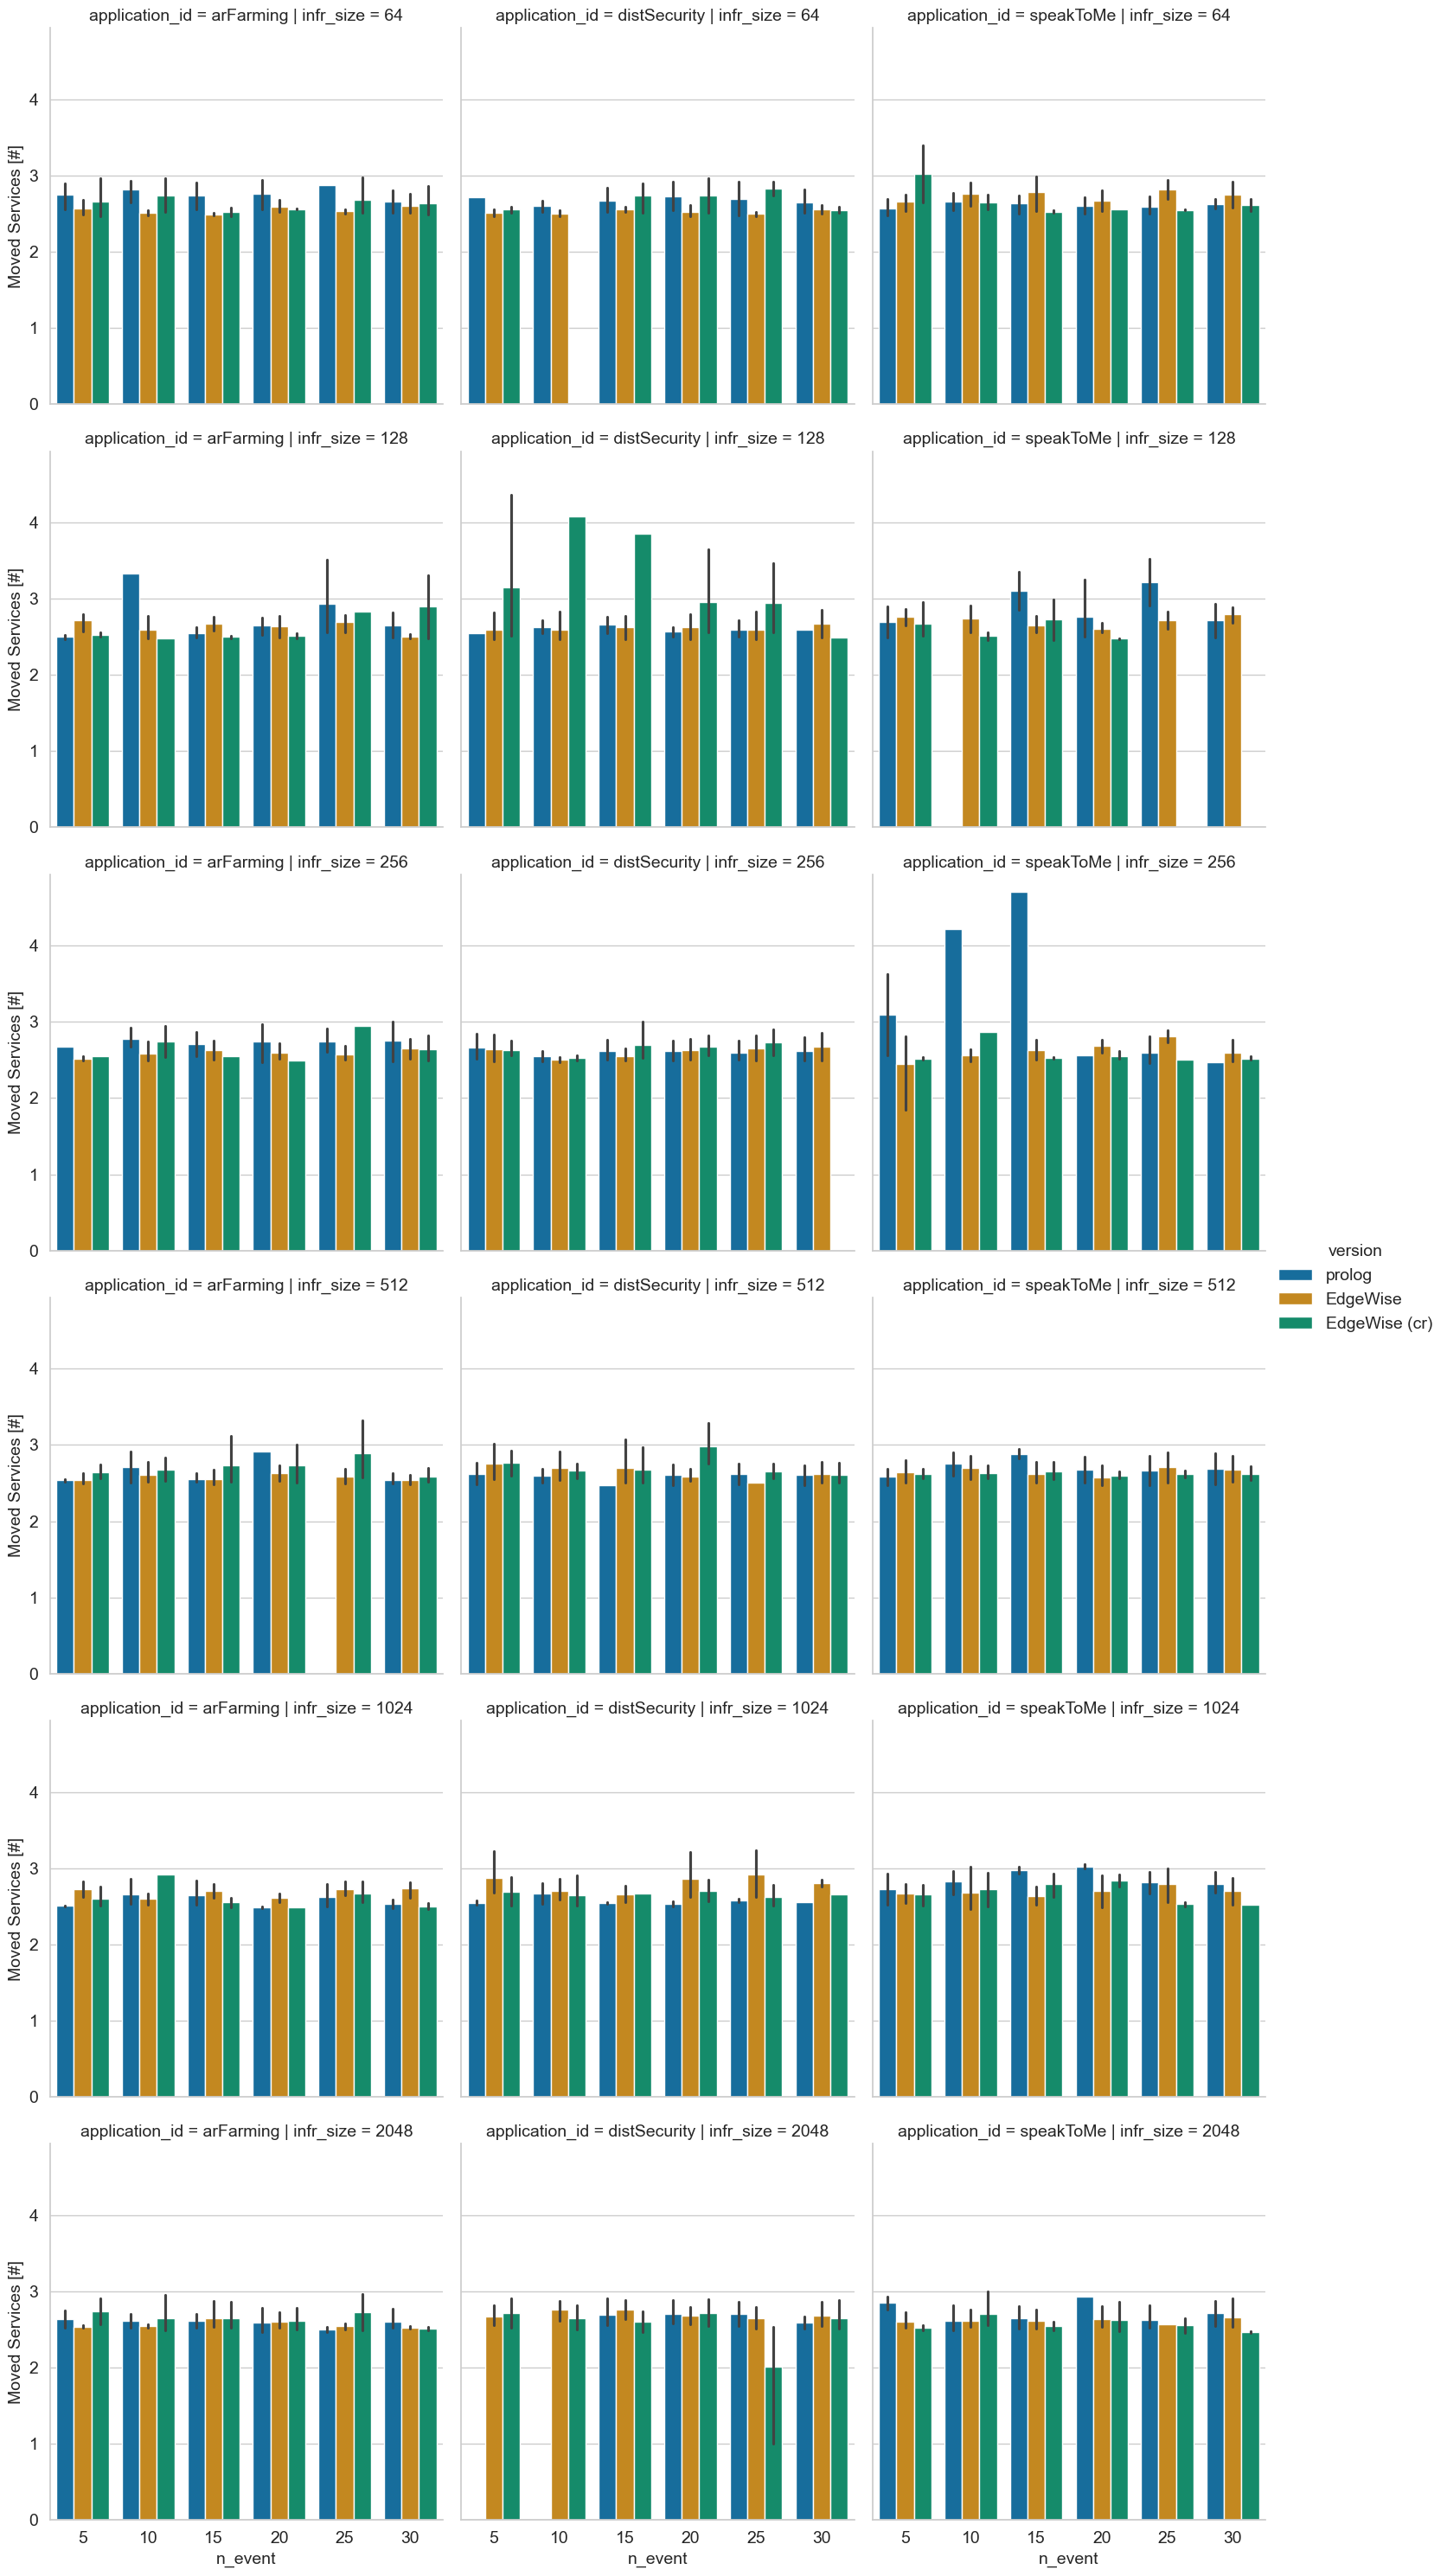

In [6]:
df_moved = df[(df["callback_id"] == "moved_services")
            & (~df["value"].isin(["inf", "0"]))
            & (df["n_event"] % 5 == 0) 
        ]
df_moved.loc[:, "value"] = df_moved["value"].astype(float).expanding().mean()
f = sns.catplot(
    data=df_moved,
    x="n_event",
    y="value",
    hue="version",
    #style="version",
    kind="bar",
    row="nodes",
    col="application_id",
    palette="colorblind",
    hue_order=HUE_ORDER,
    col_order=COL_ORDER,
)

f.set_titles("application_id = {col_name} | infr_size = {row_name}")
f.set_ylabels("Moved Services [#]")